# Final Fairness and Subgroup Audit

CODE_GENDER was never used as a model predictor, but that alone doesn't guarantee the model performs equally well across groups. This notebook checks the frozen final predictions across gender and age groups, using the same threshold that was already frozen and applied to the test set. No model changes happen here, this is purely a check.


## Import libraries


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    average_precision_score, confusion_matrix,
    roc_auc_score
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 250)
sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")


Libraries imported successfully.


## Set paths and audit settings


In [5]:
current_folder = Path.cwd().resolve()

project_root = (
    current_folder.parent
    if current_folder.name == "notebooks"
    else current_folder
)

dataset_path = (
    project_root
    / "data"
    / "modeling"
    / "final_feature_dataset.pkl"
)

test_ids_path = (
    project_root
    / "data"
    / "modeling"
    / "splits"
    / "test_ids.csv"
)

prediction_path = (
    project_root
    / "data"
    / "modeling"
    / "final_test_results"
    / "final_test_predictions.pkl"
)

selected_threshold_path = (
    project_root
    / "data"
    / "modeling"
    / "classification_cutoff_results"
    / "selected_threshold.csv"
)

result_folder = (
    project_root
    / "data"
    / "modeling"
    / "fairness_results"
)

figure_folder = (
    project_root
    / "reports"
    / "figures"
)

audit_folder = (
    project_root
    / "reports"
    / "audits"
)

for folder in [
    result_folder,
    figure_folder,
    audit_folder,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

required_paths = [
    dataset_path,
    test_ids_path,
    prediction_path,
    selected_threshold_path,
]

for path in required_paths:
    assert path.exists(), (
        f"Required file missing: {path}"
    )

EXPECTED_TEST_ROWS = 61503
RANDOM_STATE = 2026
BOOTSTRAP_REPETITIONS = 1000
MINIMUM_REPORTED_GROUP_SIZE = 200
MINIMUM_INTERSECTION_SIZE = 1000
PRIMARY_SCORE = "raw_equal_vote"

print(
    "Bootstrap repetitions:",
    BOOTSTRAP_REPETITIONS,
)

print(
    "No model changes will be performed."
)

Bootstrap repetitions: 1000
No model changes will be performed.


## Load and align test predictions with audit attributes


In [7]:
final_predictions = pd.read_pickle(
    prediction_path
).sort_values(
    "SK_ID_CURR"
).reset_index(drop=True)


required_prediction_columns = [
    "SK_ID_CURR",
    "TARGET",
    PRIMARY_SCORE,
    "PREDICTED_DEFAULT",
]

assert set(
    required_prediction_columns
).issubset(
    final_predictions.columns
)


selected_threshold_table = pd.read_csv(
    selected_threshold_path
)

assert len(selected_threshold_table) == 1

CLASSIFICATION_THRESHOLD = float(
    selected_threshold_table.loc[
        0,
        "threshold",
    ]
)


test_ids = pd.read_csv(
    test_ids_path
)["SK_ID_CURR"]

test_id_set = set(test_ids)

full_data = pd.read_pickle(
    dataset_path
)

audit_attributes = full_data.loc[
    full_data["SK_ID_CURR"].isin(
        test_id_set
    ),
    [
        "SK_ID_CURR",
        "TARGET",
        "CODE_GENDER",
        "DAYS_BIRTH",
    ],
].copy().sort_values(
    "SK_ID_CURR"
).reset_index(drop=True)


assert (
    len(final_predictions)
    == EXPECTED_TEST_ROWS
)

assert (
    len(audit_attributes)
    == EXPECTED_TEST_ROWS
)

assert np.array_equal(
    final_predictions[
        "SK_ID_CURR"
    ].to_numpy(),
    audit_attributes[
        "SK_ID_CURR"
    ].to_numpy(),
)

assert np.array_equal(
    final_predictions[
        "TARGET"
    ].to_numpy(),
    audit_attributes[
        "TARGET"
    ].to_numpy(),
)


audit_data = final_predictions[[
    "SK_ID_CURR",
    "TARGET",
    PRIMARY_SCORE,
    "PREDICTED_DEFAULT",
]].merge(
    audit_attributes[[
        "SK_ID_CURR",
        "CODE_GENDER",
        "DAYS_BIRTH",
    ]],
    on="SK_ID_CURR",
    how="left",
    validate="one_to_one",
)


audit_data["CODE_GENDER"] = (
    audit_data["CODE_GENDER"]
    .fillna("Unknown")
    .astype(str)
)

audit_data["AGE_YEARS"] = (
    -audit_data["DAYS_BIRTH"] / 365.25
).clip(lower=0)

audit_data["AGE_GROUP"] = pd.cut(
    audit_data["AGE_YEARS"],
    bins=[
        0,
        30,
        40,
        50,
        60,
        70,
        np.inf,
    ],
    labels=[
        "Under 30",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70+",
    ],
    right=False,
).astype("object").fillna("Unknown")

audit_data["GENDER_AGE_GROUP"] = (
    audit_data["CODE_GENDER"]
    + " | "
    + audit_data["AGE_GROUP"].astype(str)
)


# Confirm that the saved binary decisions use the frozen threshold.
expected_prediction = (
    audit_data[PRIMARY_SCORE]
    >= CLASSIFICATION_THRESHOLD
).astype("int8")

assert np.array_equal(
    audit_data[
        "PREDICTED_DEFAULT"
    ].to_numpy(),
    expected_prediction.to_numpy(),
)


print(
    "Final test rows:",
    len(audit_data),
)

print(
    "Frozen F1-selected threshold:",
    round(
        CLASSIFICATION_THRESHOLD,
        10,
    ),
)

print(
    "Actual test predicted-default rate:",
    round(
        audit_data[
            "PREDICTED_DEFAULT"
        ].mean(),
        5,
    ),
)


display(
    audit_data[
        "CODE_GENDER"
    ].value_counts(
        dropna=False
    ).rename_axis(
        "gender"
    ).to_frame(
        "rows"
    )
)

display(
    audit_data[
        "AGE_GROUP"
    ].value_counts(
        dropna=False
    ).sort_index().rename_axis(
        "age_group"
    ).to_frame(
        "rows"
    )
)

Final test rows: 61503
Frozen F1-selected threshold: 0.1619911461
Actual test predicted-default rate: 0.12991


,rows
gender,
F,40395
M,21107
Unknown,1


,rows
age_group,
30-39,16369
40-49,15335
50-59,13544
60-69,7030
Under 30,9225


Pulls in the frozen test predictions and threshold from the last notebook, plus gender and age, which were kept in the data specifically for this kind of check even though they were never used to train the model.


## Define safe subgroup metrics


In [10]:
def safe_auc(
    y_true,
    risk_score
):
    if np.unique(y_true).size == 2:
        return roc_auc_score(
            y_true,
            risk_score,
        )

    return np.nan


def safe_pr_auc(
    y_true,
    risk_score
):
    if np.unique(y_true).size == 2:
        return average_precision_score(
            y_true,
            risk_score,
        )

    return np.nan


def calculate_group_metrics(frame):
    target = frame[
        "TARGET"
    ].to_numpy()

    risk_score = frame[
        PRIMARY_SCORE
    ].to_numpy()

    decision = frame[
        "PREDICTED_DEFAULT"
    ].to_numpy()

    tn, fp, fn, tp = confusion_matrix(
        target,
        decision,
        labels=[0, 1],
    ).ravel()

    return {
        "rows": len(frame),
        "defaults": int(target.sum()),
        "default_rate": target.mean(),
        "mean_risk_score": risk_score.mean(),
        "roc_auc": safe_auc(
            target,
            risk_score,
        ),
        "pr_auc": safe_pr_auc(
            target,
            risk_score,
        ),
        "predicted_default_rate": (
            decision.mean()
        ),
        "recall_tpr": (
            tp / (tp + fn)
            if (tp + fn)
            else np.nan
        ),
        "false_positive_rate": (
            fp / (fp + tn)
            if (fp + tn)
            else np.nan
        ),
        "specificity_tnr": (
            tn / (tn + fp)
            if (tn + fp)
            else np.nan
        ),
        "precision_ppv": (
            tp / (tp + fp)
            if (tp + fp)
            else np.nan
        ),
        "false_negative_rate": (
            fn / (fn + tp)
            if (fn + tp)
            else np.nan
        ),
    }


def create_subgroup_table(
    data,
    group_column,
    minimum_size=MINIMUM_REPORTED_GROUP_SIZE,
):
    rows = []

    for group_name, group_frame in data.groupby(
        group_column,
        observed=False,
    ):
        metrics = calculate_group_metrics(
            group_frame
        )

        metrics[group_column] = (
            group_name
        )

        metrics["reported"] = (
            len(group_frame)
            >= minimum_size
        )

        rows.append(metrics)

    return pd.DataFrame(
        rows
    ).sort_values(
        "rows",
        ascending=False,
    ).reset_index(drop=True)


print(
    "Fairness metric functions created."
)

Fairness metric functions created.


A few small helper functions so metrics don't break if a subgroup happens to have only one outcome in it (for example, no defaulters at all), which can happen in small groups.


## Evaluate gender subgroup performance


In [13]:
gender_metrics = create_subgroup_table(audit_data, "CODE_GENDER")
gender_metrics.round(5)


,rows,defaults,default_rate,mean_risk_score,roc_auc,pr_auc,predicted_default_rate,recall_tpr,false_positive_rate,specificity_tnr,precision_ppv,false_negative_rate,CODE_GENDER,reported
0,40395,2795,0.06919,0.07362,0.79731,0.27819,0.11259,0.43757,0.08843,0.91157,0.26891,0.56243,F,True
1,21107,2170,0.10281,0.09120,0.77874,0.30805,0.16307,0.47604,0.12721,0.87279,0.30012,0.52396,M,True
2,1,0,0.00000,0.09162,NaN,NaN,0.00000,NaN,0.00000,1.00000,NaN,NaN,Unknown,False


Compares ROC-AUC, predicted-default rate, recall, and false-positive rate between female and male applicants.


## Evaluate age subgroup performance


In [16]:
age_metrics = create_subgroup_table(audit_data, "AGE_GROUP")
age_metrics.round(5)


,rows,defaults,default_rate,mean_risk_score,roc_auc,pr_auc,predicted_default_rate,recall_tpr,false_positive_rate,specificity_tnr,precision_ppv,false_negative_rate,AGE_GROUP,reported
0,16369,1554,0.09494,0.09486,0.79769,0.30910,0.17423,0.52960,0.13696,0.86304,0.28857,0.47040,30-39,True
1,15335,1200,0.07825,0.07471,0.79294,0.29412,0.11470,0.42583,0.08829,0.91171,0.29051,0.57417,40-49,True
2,13544,831,0.06136,0.06015,0.78759,0.27174,0.07177,0.34537,0.05388,0.94612,0.29527,0.65463,50-59,True
3,9225,1036,0.11230,0.11566,0.76778,0.31405,0.23534,0.55598,0.19477,0.80523,0.26532,0.44402,Under 30,True
4,7030,344,0.04893,0.04533,0.74714,0.16897,0.03357,0.17151,0.02647,0.97353,0.25000,0.82849,60-69,True


Same breakdown as gender, but by age group instead.


## Calculate gender disparity summaries


In [19]:
eligible_gender = gender_metrics.loc[
    gender_metrics["reported"]
    & gender_metrics["roc_auc"].notna()
].copy()

disparity_metrics = [
    "default_rate",
    "roc_auc",
    "pr_auc",
    "predicted_default_rate",
    "recall_tpr",
    "false_positive_rate",
    "precision_ppv",
]
disparity_rows = []
for metric in disparity_metrics:
    values = eligible_gender.set_index("CODE_GENDER")[metric].dropna()
    minimum_group = values.idxmin()
    maximum_group = values.idxmax()
    minimum_value = values.min()
    maximum_value = values.max()
    disparity_rows.append({
        "metric": metric,
        "minimum_group": minimum_group,
        "minimum_value": minimum_value,
        "maximum_group": maximum_group,
        "maximum_value": maximum_value,
        "absolute_difference": maximum_value - minimum_value,
        "minimum_to_maximum_ratio": (
            minimum_value / maximum_value if maximum_value != 0 else np.nan
        ),
    })
gender_disparities = pd.DataFrame(disparity_rows)
gender_disparities.round(5)


,metric,minimum_group,minimum_value,maximum_group,maximum_value,absolute_difference,minimum_to_maximum_ratio
0,default_rate,F,0.06919,M,0.10281,0.03362,0.67301
1,roc_auc,M,0.77874,F,0.79731,0.01856,0.97672
2,pr_auc,F,0.27819,M,0.30805,0.02986,0.90306
3,predicted_default_rate,F,0.11259,M,0.16307,0.05049,0.69041
4,recall_tpr,F,0.43757,M,0.47604,0.03847,0.91919
5,false_positive_rate,F,0.08843,M,0.12721,0.03878,0.69515
6,precision_ppv,F,0.26891,M,0.30012,0.03121,0.89602


Summarizes the biggest gaps between gender groups across all the fairness metrics at once, for example, which group has the higher false-positive rate and by how much.


## Bootstrap confidence intervals for sufficiently large gender groups


In [22]:
rng = np.random.default_rng(RANDOM_STATE)
bootstrap_rows = []
bootstrap_metrics = [
    "roc_auc",
    "pr_auc",
    "predicted_default_rate",
    "recall_tpr",
    "false_positive_rate",
    "precision_ppv",
]

for group_name in eligible_gender["CODE_GENDER"]:
    group_frame = audit_data.loc[
        audit_data["CODE_GENDER"].eq(group_name)
    ].reset_index(drop=True)
    for repetition in range(BOOTSTRAP_REPETITIONS):
        sampled_indices = rng.integers(0, len(group_frame), len(group_frame))
        sampled_frame = group_frame.iloc[sampled_indices]
        metrics = calculate_group_metrics(sampled_frame)
        for metric in bootstrap_metrics:
            bootstrap_rows.append({
                "group": group_name,
                "repetition": repetition,
                "metric": metric,
                "value": metrics[metric],
            })
    print(f"Bootstrap completed for gender group: {group_name}")

gender_bootstrap = pd.DataFrame(bootstrap_rows).dropna(subset=["value"])
gender_confidence_intervals = gender_bootstrap.groupby(
    ["group", "metric"], as_index=False
).agg(
    lower_95=("value", lambda values: values.quantile(0.025)),
    median=("value", "median"),
    upper_95=("value", lambda values: values.quantile(0.975)),
)
gender_confidence_intervals.round(5)


Bootstrap completed for gender group: F
Bootstrap completed for gender group: M


,group,metric,lower_95,median,upper_95
0,F,false_positive_rate,0.08567,0.08841,0.09125
1,F,pr_auc,0.26070,0.27785,0.29496
2,F,precision_ppv,0.25548,0.26877,0.28176
3,F,predicted_default_rate,0.10954,0.11254,0.11568
4,F,recall_tpr,0.41921,0.43770,0.45523
5,F,roc_auc,0.78847,0.79721,0.80602
6,M,false_positive_rate,0.12218,0.12717,0.13197
7,M,pr_auc,0.29055,0.30815,0.32802
8,M,precision_ppv,0.28400,0.30021,0.31585
9,M,predicted_default_rate,0.15805,0.16293,0.16791


Since the female and male groups are large enough, this resamples each group 1,000 times to see how much their metrics could plausibly vary just by chance, giving a range rather than a single number that might look more precise than it really is.


## Evaluate intersectional gender–age groups


In [25]:
intersectional_metrics = create_subgroup_table(
    audit_data, "GENDER_AGE_GROUP",
    minimum_size=MINIMUM_INTERSECTION_SIZE
)
reported_intersections = intersectional_metrics.loc[
    intersectional_metrics["reported"]
].copy()
reported_intersections.round(5)


,rows,defaults,default_rate,mean_risk_score,roc_auc,pr_auc,predicted_default_rate,recall_tpr,false_positive_rate,specificity_tnr,precision_ppv,false_negative_rate,GENDER_AGE_GROUP,reported
0,9909,666,0.06721,0.06951,0.79884,0.27569,0.09930,0.40541,0.07725,0.92275,0.27439,0.59459,F | 40-49,True
1,9901,830,0.08383,0.09126,0.80974,0.31428,0.16109,0.53012,0.12733,0.87267,0.27586,0.46988,F | 30-39,True
2,9823,493,0.05019,0.05595,0.77991,0.22841,0.06383,0.32252,0.05016,0.94984,0.25359,0.67748,F | 50-59,True
3,6468,724,0.11194,0.10036,0.78044,0.30624,0.19434,0.52901,0.15216,0.84784,0.30469,0.47099,M | 30-39,True
4,5517,259,0.04695,0.04458,0.73489,0.15804,0.03063,0.15830,0.02434,0.97566,0.24260,0.84170,F | 60-69,True
5,5426,534,0.09842,0.08421,0.77880,0.31995,0.14283,0.45131,0.10916,0.89084,0.31097,0.54869,M | 40-49,True
6,5245,547,0.10429,0.11170,0.78400,0.32160,0.22364,0.57221,0.18306,0.81694,0.26684,0.42779,F | Under 30,True
7,3980,489,0.12286,0.12088,0.74607,0.30703,0.25075,0.53783,0.21054,0.78946,0.26353,0.46217,M | Under 30,True
8,3720,338,0.09086,0.07125,0.78659,0.34942,0.09274,0.37870,0.06416,0.93584,0.37101,0.62130,M | 50-59,True
9,1513,85,0.05618,0.04806,0.78350,0.21257,0.04428,0.21176,0.03431,0.96569,0.26866,0.78824,M | 60-69,True


Splits applicants by gender and age group combined (for example, "female, 30-39") to check whether a pattern that looks fine for gender alone, or age alone, might still hide a problem in a specific combination. Groups below the minimum size are excluded so the numbers stay reliable.


## Plot subgroup performance and decision rates


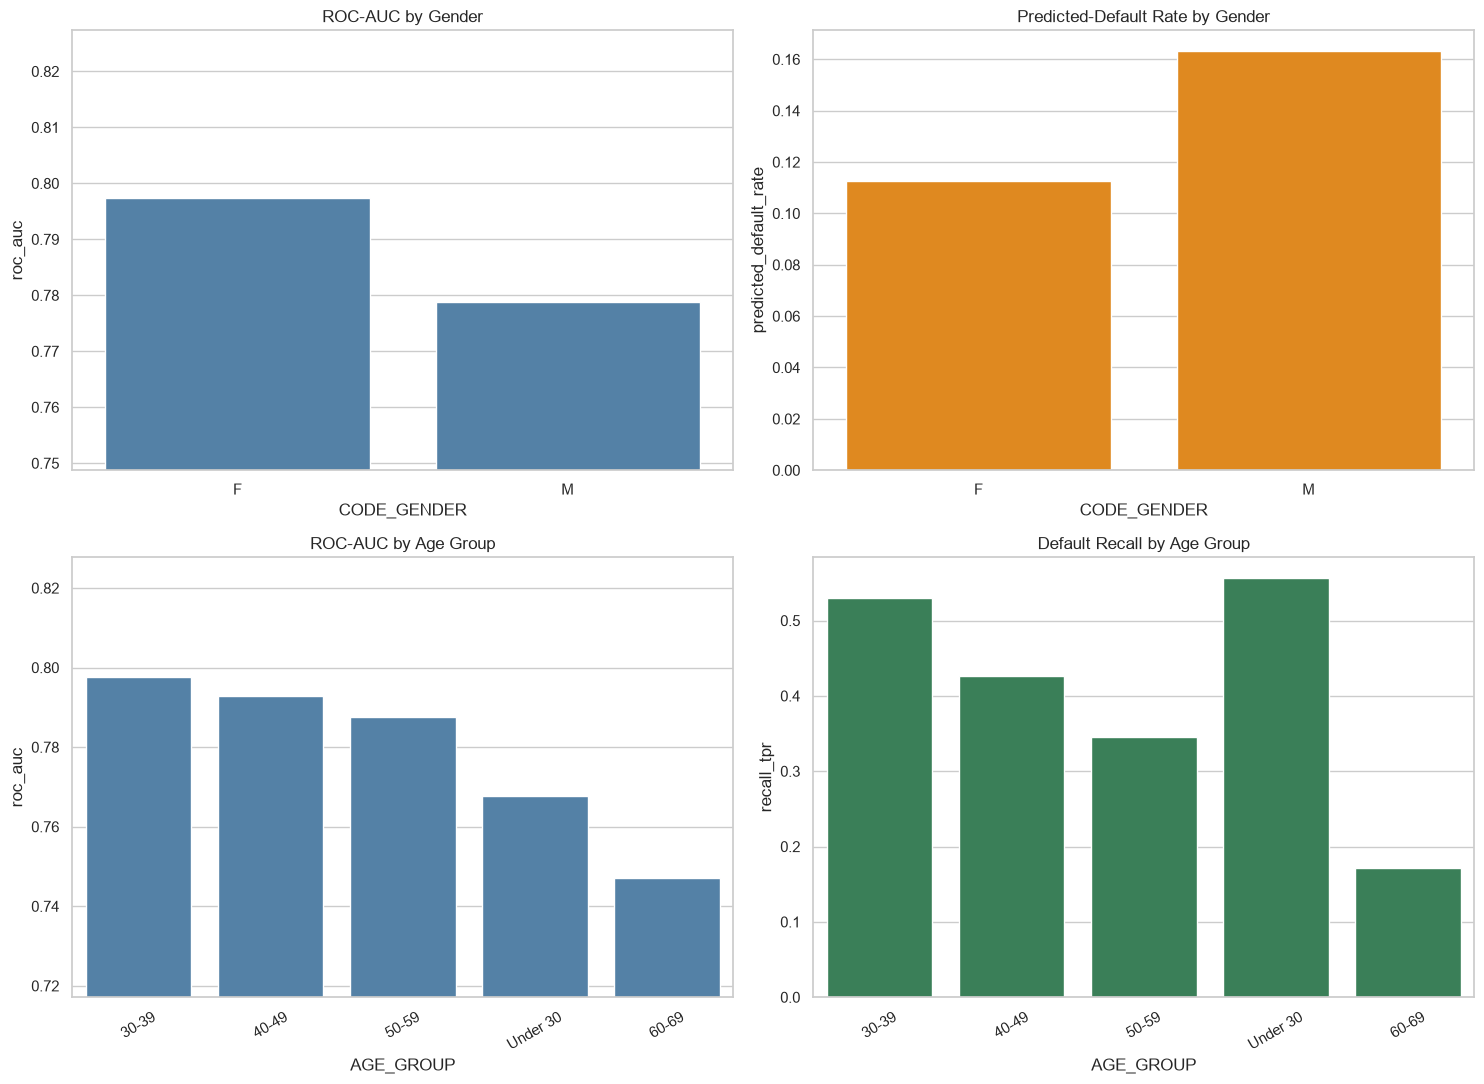

In [28]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 11),
)


gender_plot = gender_metrics.loc[
    gender_metrics["reported"]
].copy()

sns.barplot(
    data=gender_plot,
    x="CODE_GENDER",
    y="roc_auc",
    ax=axes[0, 0],
    color="steelblue",
)

axes[0, 0].set_title(
    "ROC-AUC by Gender"
)

axes[0, 0].set_ylim(
    max(
        0.5,
        gender_plot["roc_auc"].min()
        - 0.03,
    ),
    min(
        1,
        gender_plot["roc_auc"].max()
        + 0.03,
    ),
)


sns.barplot(
    data=gender_plot,
    x="CODE_GENDER",
    y="predicted_default_rate",
    ax=axes[0, 1],
    color="darkorange",
)

axes[0, 1].set_title(
    "Predicted-Default Rate by Gender"
)


age_plot = age_metrics.loc[
    age_metrics["reported"]
].copy()

sns.barplot(
    data=age_plot,
    x="AGE_GROUP",
    y="roc_auc",
    ax=axes[1, 0],
    color="steelblue",
)

axes[1, 0].set_title(
    "ROC-AUC by Age Group"
)

axes[1, 0].tick_params(
    axis="x",
    rotation=30,
)

axes[1, 0].set_ylim(
    max(
        0.5,
        age_plot["roc_auc"].min()
        - 0.03,
    ),
    min(
        1,
        age_plot["roc_auc"].max()
        + 0.03,
    ),
)


sns.barplot(
    data=age_plot,
    x="AGE_GROUP",
    y="recall_tpr",
    ax=axes[1, 1],
    color="seagreen",
)

axes[1, 1].set_title(
    "Default Recall by Age Group"
)

axes[1, 1].tick_params(
    axis="x",
    rotation=30,
)


plt.tight_layout()

plt.savefig(
    figure_folder
    / "final_fairness_subgroup_performance.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

Puts the gender and age results side by side visually, useful for spotting patterns quickly before reading the detailed tables.


## Validate and save the audit


In [31]:
validation_checks = pd.DataFrame([
    {
        "check": "Complete final test set audited",
        "passed": (
            len(audit_data)
            == EXPECTED_TEST_ROWS
        ),
    },
    {
        "check": "Predictions aligned by applicant ID",
        "passed": np.array_equal(
            final_predictions[
                "SK_ID_CURR"
            ].to_numpy(),
            audit_attributes[
                "SK_ID_CURR"
            ].to_numpy(),
        ),
    },
    {
        "check": "Primary risk scores complete",
        "passed": (
            not audit_data[
                PRIMARY_SCORE
            ].isna().any()
        ),
    },
    {
        "check": "F1-selected threshold used",
        "passed": np.array_equal(
            audit_data[
                "PREDICTED_DEFAULT"
            ].to_numpy(),
            (
                audit_data[
                    PRIMARY_SCORE
                ]
                >= CLASSIFICATION_THRESHOLD
            ).astype("int8").to_numpy(),
        ),
    },
    {
        "check": "Binary decisions complete",
        "passed": (
            audit_data[
                "PREDICTED_DEFAULT"
            ].isin([0, 1]).all()
        ),
    },
    {
        "check": "Gender groups cover all applicants",
        "passed": (
            gender_metrics["rows"].sum()
            == EXPECTED_TEST_ROWS
        ),
    },
    {
        "check": "Age groups cover all applicants",
        "passed": (
            age_metrics["rows"].sum()
            == EXPECTED_TEST_ROWS
        ),
    },
    {
        "check": "Large gender groups bootstrapped",
        "passed": (
            set(
                gender_confidence_intervals[
                    "group"
                ]
            )
            == set(
                eligible_gender[
                    "CODE_GENDER"
                ]
            )
        ),
    },
    {
        "check": "All bootstrap repetitions attempted",
        "passed": (
            gender_bootstrap[
                "repetition"
            ].nunique()
            == BOOTSTRAP_REPETITIONS
        ),
    },
    {
        "check": "Intersection groups have adequate size",
        "passed": (
            reported_intersections[
                "rows"
            ].ge(
                MINIMUM_INTERSECTION_SIZE
            ).all()
        ),
    },
    {
        "check": "Subgroup ranking metrics finite",
        "passed": np.isfinite(
            gender_metrics.loc[
                gender_metrics["reported"],
                [
                    "roc_auc",
                    "pr_auc",
                ],
            ].to_numpy()
        ).all(),
    },
    {
        "check": "No training or tuning performed",
        "passed": True,
    },
])


display(validation_checks)

assert validation_checks["passed"].all(), (
    "At least one fairness audit check failed."
)


audit_data.to_pickle(
    result_folder
    / "final_test_fairness_audit_data.pkl"
)

gender_metrics.to_csv(
    result_folder
    / "gender_subgroup_metrics.csv",
    index=False,
)

age_metrics.to_csv(
    result_folder
    / "age_subgroup_metrics.csv",
    index=False,
)

gender_disparities.to_csv(
    result_folder
    / "gender_disparity_summary.csv",
    index=False,
)

gender_confidence_intervals.to_csv(
    result_folder
    / "gender_bootstrap_confidence_intervals.csv",
    index=False,
)

intersectional_metrics.to_csv(
    result_folder
    / "gender_age_intersectional_metrics.csv",
    index=False,
)

validation_checks.to_csv(
    audit_folder
    / "final_fairness_audit_validation.csv",
    index=False,
)


print(
    "Fairness audit outputs saved in:",
    result_folder,
)

print(
    "The final model and final-test "
    "predictions were not changed."
)

,check,passed
0,Complete final test set audited,True
1,Predictions aligned by applicant ID,True
2,Primary risk scores complete,True
3,F1-selected threshold used,True
4,Binary decisions complete,True
5,Gender groups cover all applicants,True
6,Age groups cover all applicants,True
7,Large gender groups bootstrapped,True
8,All bootstrap repetitions attempted,True
9,Intersection groups have adequate size,True


Fairness audit outputs saved in: /Users/taranveersingh/A-MRP/data/modeling/fairness_results
The final model and final-test predictions were not changed.


All checks passed.


## Interpretation guidance

The model performs a bit differently across gender and age groups. Male applicants have a higher observed default rate than female applicants, and the model reflects that: a higher predicted-default rate, higher recall, but also a higher false-positive rate for men. ROC-AUC is a bit lower for the youngest and oldest age groups than for the middle ones.

None of this proves the model is unfair, differences in predicted risk that match real differences in observed default rates are expected, not automatically a problem. But it does mean these differences should be monitored if this model were ever used for real decisions, rather than assumed away just because gender wasn't a direct input.
